# 01. Profiling: Customers Dataset
This notebook profiles `olist_customers_dataset.csv`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/olist_customers_dataset.csv')
print(f"Shape: {df.shape}\n")
print(df.dtypes)
df.head()

Shape: (99441, 5)

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'count': missing, 'pct': missing_pct})

,count,pct
customer_id,0,0.0
customer_unique_id,0,0.0
customer_zip_code_prefix,0,0.0
customer_city,0,0.0
customer_state,0,0.0


In [5]:
# Duplicates and Uniqueness
print(f"Full row duplicates: {df.duplicated().sum()}")
print(f"customer_id duplicates: {df.duplicated(subset=['customer_id']).sum()}")
print(f"Row count == Distinct customer_id: {df.shape[0] == df['customer_id'].nunique()}")

Full row duplicates: 0
customer_id duplicates: 0
Row count == Distinct customer_id: True


In [6]:
# Specific checks: distinct customer_id vs customer_unique_id
c_id_count = df['customer_id'].nunique()
c_uid_count = df['customer_unique_id'].nunique()
print(f"Distinct customer_id: {c_id_count}")
print(f"Distinct customer_unique_id: {c_uid_count}")
print(f"Repeat purchases (gap): {c_id_count - c_uid_count}")

Distinct customer_id: 99441
Distinct customer_unique_id: 96096
Repeat purchases (gap): 3345


customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
SC     3.657445
BA     3.399000
DF     2.152030
ES     2.044428
GO     2.031355
Name: proportion, dtype: float64


<Axes: title={'center': 'Top 10 Customer States (%)'}, xlabel='customer_state'>

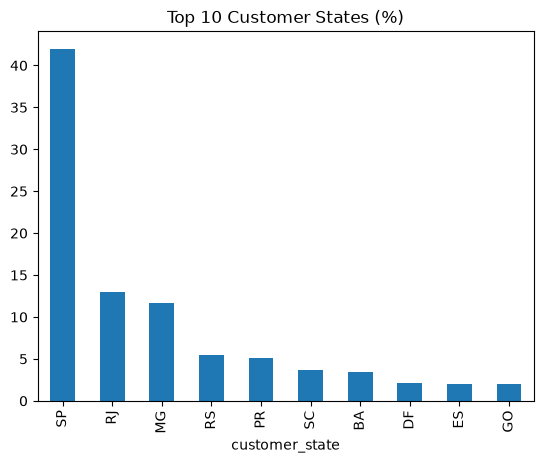

In [7]:
# Specific checks: customer_state distribution
state_dist = df['customer_state'].value_counts(normalize=True) * 100
print(state_dist.head(10))
state_dist.head(10).plot(kind='bar', title='Top 10 Customer States (%)')

## Summary Findings
- **Perfect Uniqueness & Completeness:** The dataset is perfectly clean in terms of completeness—there are zero missing values and zero duplicate rows. `customer_id` acts as a true primary key for this table (99,441 rows and exactly 99,441 unique `customer_id`s).
- **Repeat Purchases Exist:** There are 96,096 distinct `customer_unique_id`s compared to 99,441 `customer_id`s. This gap reveals approximately 3,345 repeat purchases (around 3.4% of total orders).
- **High Geographic Concentration:** The customer base is heavily concentrated in the state of São Paulo (SP), which alone accounts for ~42% of all customers. The top three states (SP, RJ, and MG) combined account for roughly 66% of the customer base.